# Pharma Compliance Spend Analytics — ML Anomaly Detection Layer

**Continuation of [`01_data_features.ipynb`](./01_data_features.ipynb).** Notebook 01 built a rule-based anomaly detection system (within-specialty z-score, global IQR, concentration rule) producing a tiered risk classifier with a 1.67% HIGH-tier flag rate.

This notebook adds an **unsupervised ML layer** using Isolation Forest, then reconciles the two flag sets to answer the question every compliance team eventually asks: *what does each method catch that the other misses?*

**What this notebook does:**
1. Loads the 289K-HCP feature table from notebook 01
2. Fits an Isolation Forest on the 5 engineered features with `contamination=0.02` (matched to the rule-based HIGH rate so the comparison is apples-to-apples)
3. Adds an `ml_anomaly_flag` column to the HCP table
4. Quantifies the overlap between rule-HIGH and ML-flagged sets — both/either/neither
5. Profiles the ML-only and rule-only flag populations to characterize what each method uniquely catches
6. Exports an enriched CSV for downstream analysis

**Why both methods?** Rules are explainable (every flag has a one-sentence justification) and compliance leadership demands that. ML catches multivariate patterns no single rule can express. The pair is stronger than either alone.

**Author:** Shrikant Sharma — Data Scientist (Pharma & Financial Services)

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
np.random.seed(42)

print("Imports OK")

Imports OK


In [2]:
hcp = pd.read_csv("../output/hcp_features_with_flags.csv")

print(f"Shape: {hcp.shape}")
print(f"\nColumns:\n{list(hcp.columns)}")
print(f"\nRisk tier distribution:")
print(hcp['risk_tier'].value_counts(dropna=False))
print(f"\nHIGH-tier rate: {(hcp['risk_tier'] == 'HIGH').mean() * 100:.2f}%")

Shape: (288942, 25)

Columns:
['Covered_Recipient_NPI', 'first_name', 'last_name', 'specialty', 'primary_state', 'total_payment_value', 'payment_frequency', 'avg_payment_size', 'n_unique_states', 'top_company_share', 'top_company_name', 'top_company_total', 'specialty_size', 'has_specialty_zscore', 'total_payment_value_zscore', 'payment_frequency_zscore', 'avg_payment_size_zscore', 'total_payment_value_iqr_outlier', 'payment_frequency_iqr_outlier', 'avg_payment_size_iqr_outlier', 'signal_high_value', 'signal_high_frequency', 'signal_concentrated', 'n_signals', 'risk_tier']

Risk tier distribution:
risk_tier
NONE      237928
MEDIUM     23423
LOW        22772
HIGH        4819
Name: count, dtype: int64

HIGH-tier rate: 1.67%


## Why Isolation Forest?

Three reasons it fits this problem:

1. **Unsupervised.** CMS publishes the payments but doesn't tell us which physicians are *actually* under compliance investigation. There are no labels. Isolation Forest learns "what's normal" from the data itself and flags outliers without supervision.

2. **Multivariate.** The rule-based system fires on individual features (high total, single-manufacturer concentration). Isolation Forest considers feature *combinations* — a physician with moderately high totals AND unusual geographic spread AND moderate concentration might trip no individual rule but still be unusual in combination. That's the multivariate signal rules can't capture.

3. **Scale-invariant.** It's tree-based — splits on feature *values*, not distances — so the wildly different scales of `total_payment_value` ($0–$10M+) and `top_company_share` (0–1) don't require standardization. Trees just don't care.

**Hyperparameter choice — `contamination=0.02`.** We set the expected anomaly rate slightly above the rule-based 1.67% so the flag volumes are roughly comparable. Identical contamination would over-anchor; 0.02 gives ML modest room to disagree while keeping the comparison interpretable.

In [3]:
# The 5 engineered features (same set used by the rules)
features = [
    'total_payment_value',
    'payment_frequency',
    'avg_payment_size',
    'n_unique_states',
    'top_company_share',
]

X = hcp[features].copy()
print(f"Feature matrix shape: {X.shape}")
print(f"Any NaNs: {X.isna().any().any()}")

# Fit
iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X)

# Score and label
hcp['ml_anomaly_score'] = iso.decision_function(X)   # higher = more normal
hcp['ml_anomaly_label'] = iso.predict(X)              # -1 = anomaly, 1 = inlier
hcp['ml_anomaly_flag'] = (hcp['ml_anomaly_label'] == -1).astype(int)

# Quick summary
print(f"\nFlagged as ML anomalies: {hcp['ml_anomaly_flag'].sum():,} "
      f"({hcp['ml_anomaly_flag'].mean()*100:.2f}%)")

print(f"\nAnomaly score distribution:")
print(hcp['ml_anomaly_score'].describe())

Feature matrix shape: (288942, 5)
Any NaNs: False

Flagged as ML anomalies: 5,779 (2.00%)

Anomaly score distribution:
count    288942.000000
mean          0.265530
std           0.087811
min          -0.159440
25%           0.243433
50%           0.285765
75%           0.333473
max           0.340020
Name: ml_anomaly_score, dtype: float64


## Reconciling Rules and ML — Where do they agree, where do they diverge?

With both flag sets in place (4,819 rule-HIGH, 5,779 ML-anomaly), the operational question is: *do these methods see the same physicians, or different ones?* The answer determines whether ML is **redundant**, **complementary**, or **superior** to the rules.

We measure this four ways:

1. **2×2 contingency** — counts and percentages across the four possible label combinations.
2. **Jaccard similarity** — `|both| / |either|`. Pure set overlap, ignoring the much larger "neither" class.
3. **Sensitivity of ML to rule-HIGH** — what fraction of rule-HIGH physicians does ML also catch?
4. **Cohen's kappa** — agreement corrected for chance. Useful because with 98% of HCPs in the "neither" bucket, raw accuracy is misleading.

We then profile each subgroup (BOTH / RULE-ONLY / ML-ONLY / NEITHER) on the underlying features to characterize *what each method uniquely catches*. That's the finding that earns the resume bullet.

In [4]:
from sklearn.metrics import cohen_kappa_score

rule_high = (hcp['risk_tier'] == 'HIGH').astype(int)
ml_flag = hcp['ml_anomaly_flag']

# Contingency: counts
ct_counts = pd.crosstab(
    rule_high, ml_flag,
    rownames=['Rule HIGH'], colnames=['ML Anomaly'],
    margins=True, margins_name='Total',
)
print("Contingency table — counts:")
print(ct_counts)

# Contingency: percentages of full population
ct_pct = pd.crosstab(
    rule_high, ml_flag,
    rownames=['Rule HIGH'], colnames=['ML Anomaly'],
    normalize='all', margins=True, margins_name='Total',
) * 100
print("\nContingency table — % of all HCPs:")
print(ct_pct.round(2))

# Cell counts
A = ((rule_high == 1) & (ml_flag == 1)).sum()  # both
B = ((rule_high == 1) & (ml_flag == 0)).sum()  # rule-only
C = ((rule_high == 0) & (ml_flag == 1)).sum()  # ml-only
D = ((rule_high == 0) & (ml_flag == 0)).sum()  # neither

# Agreement stats
jaccard = A / (A + B + C)
sens_ml_given_rule = A / (A + B) * 100
prec_ml_to_rule = A / (A + C) * 100
kappa = cohen_kappa_score(rule_high, ml_flag)

print(f"\n{'─' * 70}")
print(f"  Both methods flagged:          {A:>6,}")
print(f"  Rule-only (ML missed):         {B:>6,}")
print(f"  ML-only (rule missed):         {C:>6,}")
print(f"  Neither:                       {D:>6,}")
print(f"{'─' * 70}")
print(f"  Jaccard similarity:                                  {jaccard:.3f}")
print(f"  % of rule-HIGH also caught by ML:                    {sens_ml_given_rule:.1f}%")
print(f"  % of ML flags that are also rule-HIGH:               {prec_ml_to_rule:.1f}%")
print(f"  Cohen's kappa (agreement beyond chance):             {kappa:.3f}")
print(f"{'─' * 70}")

Contingency table — counts:
ML Anomaly       0     1   Total
Rule HIGH                       
0           279944  4179  284123
1             3219  1600    4819
Total       283163  5779  288942

Contingency table — % of all HCPs:
ML Anomaly      0     1   Total
Rule HIGH                      
0           96.89  1.45   98.33
1            1.11  0.55    1.67
Total       98.00  2.00  100.00

──────────────────────────────────────────────────────────────────────
  Both methods flagged:           1,600
  Rule-only (ML missed):          3,219
  ML-only (rule missed):          4,179
  Neither:                       279,944
──────────────────────────────────────────────────────────────────────
  Jaccard similarity:                                  0.178
  % of rule-HIGH also caught by ML:                    33.2%
  % of ML flags that are also rule-HIGH:               27.7%
  Cohen's kappa (agreement beyond chance):             0.289
───────────────────────────────────────────────────────────────

In [5]:
# Assign group labels
hcp['flag_group'] = np.select(
    [
        (rule_high == 1) & (ml_flag == 1),
        (rule_high == 1) & (ml_flag == 0),
        (rule_high == 0) & (ml_flag == 1),
    ],
    ['BOTH', 'RULE_ONLY', 'ML_ONLY'],
    default='NEITHER',
)

# Median feature values per group + count
profile = (
    hcp.groupby('flag_group')[features]
    .median()
    .round(2)
    .reindex(['BOTH', 'RULE_ONLY', 'ML_ONLY', 'NEITHER'])
)
profile.insert(0, 'count', hcp['flag_group'].value_counts().reindex(profile.index))
profile['count'] = profile['count'].astype(int)

print("Median feature values by flag group:")
print(profile)

Median feature values by flag group:
             count  total_payment_value  payment_frequency  avg_payment_size  n_unique_states  top_company_share
flag_group                                                                                                      
BOTH          1600             13741.86               16.0            828.30              1.0               0.93
RULE_ONLY     3219              3069.72               11.0            254.15              1.0               0.91
ML_ONLY       4179             13110.73                8.0           1528.93              1.0               0.63
NEITHER     279944                61.66                2.0             23.34              1.0               1.00


In [6]:
cols_show = [
    'Covered_Recipient_NPI', 'specialty', 'primary_state',
    'total_payment_value', 'payment_frequency', 'avg_payment_size',
    'n_unique_states', 'top_company_share', 'top_company_name',
    'n_signals', 'ml_anomaly_score',
]

print("Top 5 BOTH-flagged HCPs (consensus picks — most anomalous by ML score):")
both = hcp[hcp['flag_group'] == 'BOTH'].sort_values('ml_anomaly_score').head(5)
print(both[cols_show].to_string(index=False))

print("\nTop 5 ML-ONLY HCPs (multivariate anomalies the rules missed):")
ml_only = hcp[hcp['flag_group'] == 'ML_ONLY'].sort_values('ml_anomaly_score').head(5)
print(ml_only[cols_show].to_string(index=False))

print("\nTop 5 RULE-ONLY HCPs (rules fired, ML didn't — sorted by total payment value):")
rule_only = hcp[hcp['flag_group'] == 'RULE_ONLY'].sort_values('total_payment_value', ascending=False).head(5)
print(rule_only[cols_show].to_string(index=False))

Top 5 BOTH-flagged HCPs (consensus picks — most anomalous by ML score):
 Covered_Recipient_NPI                                                            specialty primary_state  total_payment_value  payment_frequency  avg_payment_size  n_unique_states  top_company_share             top_company_name  n_signals  ml_anomaly_score
          1891993572.0              Allopathic & Osteopathic Physicians|Orthopaedic Surgery            OH            246807.47                 38       6494.933421                2           0.992400 Zimmer Biomet Holdings, Inc.          3         -0.159440
          1003860750.0              Allopathic & Osteopathic Physicians|Orthopaedic Surgery            IL            543748.43                 29      18749.945862                1           1.000000          Stryker Corporation          3         -0.151100
          1508817693.0 Allopathic & Osteopathic Physicians|Orthopaedic Surgery|Hand Surgery            FL            261465.46                 36       72

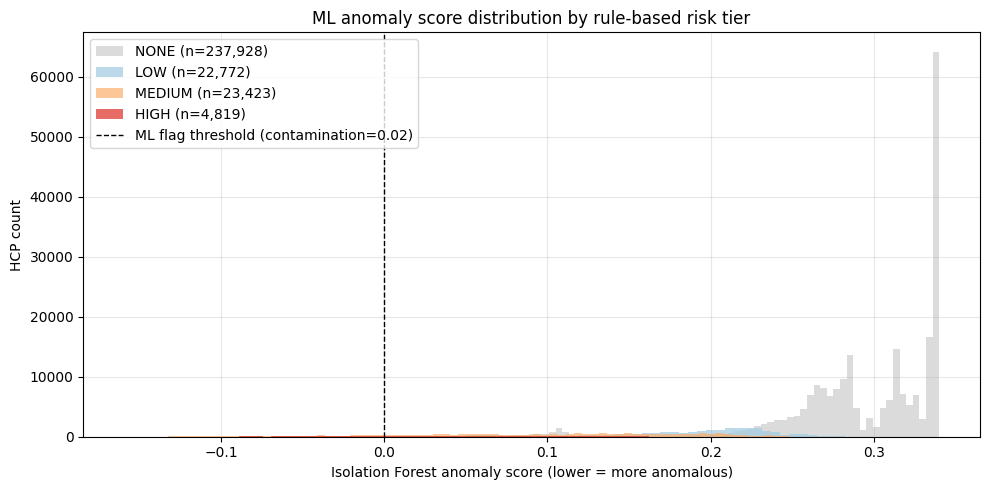

In [7]:
import os
os.makedirs("../output/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))

tier_order = ['NONE', 'LOW', 'MEDIUM', 'HIGH']
tier_colors = {'NONE': '#cccccc', 'LOW': '#9ecae1', 'MEDIUM': '#fdae6b', 'HIGH': '#de2d26'}

for tier in tier_order:
    subset = hcp[hcp['risk_tier'] == tier]['ml_anomaly_score']
    ax.hist(subset, bins=80, alpha=0.7, label=f"{tier} (n={len(subset):,})",
            color=tier_colors[tier])

ax.axvline(hcp.loc[hcp['ml_anomaly_flag'] == 1, 'ml_anomaly_score'].max(),
           color='black', linestyle='--', linewidth=1,
           label='ML flag threshold (contamination=0.02)')

ax.set_xlabel("Isolation Forest anomaly score (lower = more anomalous)")
ax.set_ylabel("HCP count")
ax.set_title("ML anomaly score distribution by rule-based risk tier")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../output/figures/ml_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

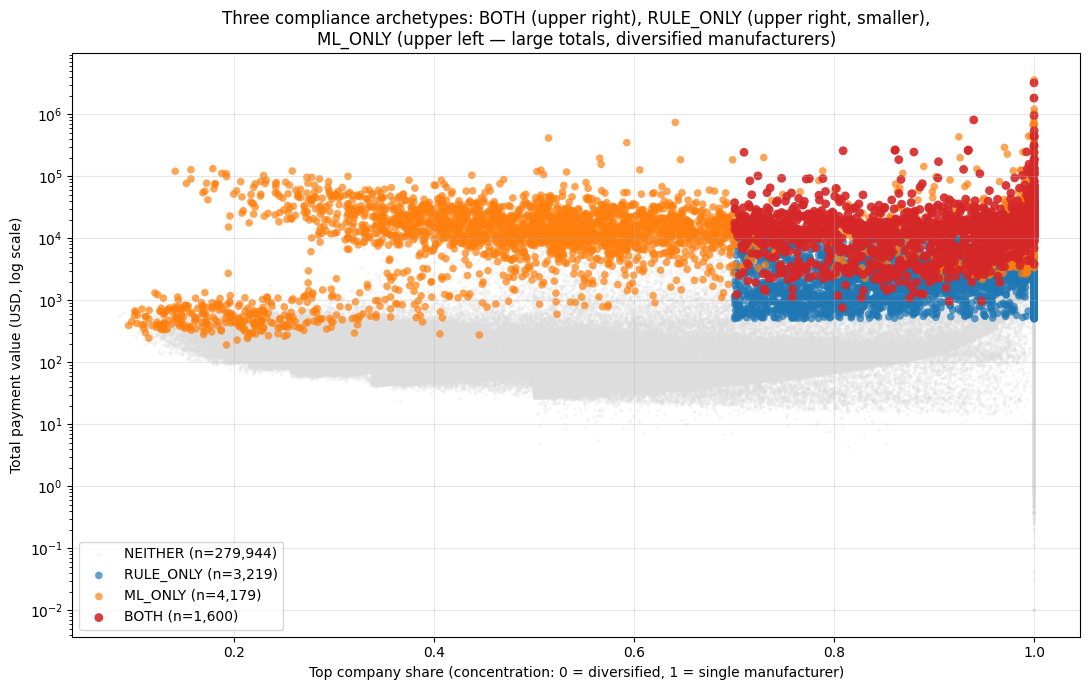

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))

group_colors = {
    'NEITHER':   ('#dddddd', 6,  0.25),
    'RULE_ONLY': ('#1f77b4', 30, 0.7),
    'ML_ONLY':   ('#ff7f0e', 30, 0.7),
    'BOTH':      ('#d62728', 40, 0.9),
}

# Plot order: background to foreground
for group in ['NEITHER', 'RULE_ONLY', 'ML_ONLY', 'BOTH']:
    subset = hcp[hcp['flag_group'] == group]
    color, size, alpha = group_colors[group]
    ax.scatter(
        subset['top_company_share'], subset['total_payment_value'],
        c=color, s=size, alpha=alpha,
        label=f"{group} (n={len(subset):,})",
        edgecolors='none',
    )

ax.set_yscale('log')
ax.set_xlabel("Top company share (concentration: 0 = diversified, 1 = single manufacturer)")
ax.set_ylabel("Total payment value (USD, log scale)")
ax.set_title("Three compliance archetypes: BOTH (upper right), RULE_ONLY (upper right, smaller),\n"
             "ML_ONLY (upper left — large totals, diversified manufacturers)")
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../output/figures/rules_vs_ml_archetypes.png", dpi=150, bbox_inches='tight')
plt.show()

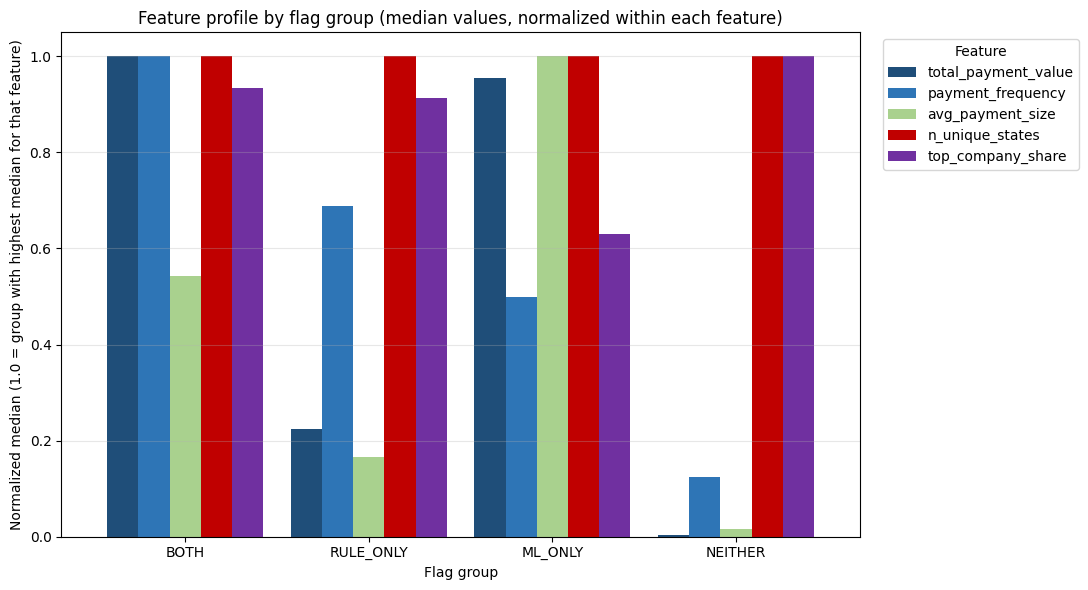

In [9]:
profile_features = hcp.groupby('flag_group')[features].median().reindex(
    ['BOTH', 'RULE_ONLY', 'ML_ONLY', 'NEITHER']
)

# Normalize each feature to its max so all 5 fit on one axis
profile_normalized = profile_features.div(profile_features.max(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(11, 6))
profile_normalized.plot(kind='bar', ax=ax, width=0.85,
                        color=['#1f4e79', '#2e75b6', '#a9d18e', '#c00000', '#7030a0'])

ax.set_title("Feature profile by flag group (median values, normalized within each feature)")
ax.set_ylabel("Normalized median (1.0 = group with highest median for that feature)")
ax.set_xlabel("Flag group")
ax.set_xticklabels(profile_normalized.index, rotation=0)
ax.legend(title='Feature', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../output/figures/feature_profile_by_group.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
out_cols = list(hcp.columns)  # all 28 columns including the new ML ones
out_path = "../output/hcp_features_with_ml_flags.csv"
hcp[out_cols].to_csv(out_path, index=False)

# Confirm
print(f"Saved: {out_path}")
print(f"Rows: {len(hcp):,}")
print(f"Columns: {len(hcp.columns)}")
print(f"New ML columns: ml_anomaly_score, ml_anomaly_label, ml_anomaly_flag, flag_group")

Saved: ../output/hcp_features_with_ml_flags.csv
Rows: 288,942
Columns: 29
New ML columns: ml_anomaly_score, ml_anomaly_label, ml_anomaly_flag, flag_group


## Summary — Three compliance archetypes

Comparing rule-based and ML anomaly detection on the same 288,942 HCPs surfaced three structurally distinct patterns of compliance risk:

| Archetype | Group | n | Profile | What flags them |
|---|---|---|---|---|
| **Captured specialist** | BOTH | 1,600 | High total, high avg payment, concentrated (0.93) — orthopedic surgery, dental | Both methods agree |
| **Captured generalist** | RULE_ONLY | 3,219 | Modest total ($3K), highly concentrated (0.91) — general practice, cardiology, oncology | Concentration rule + within-specialty z-score |
| **Industry consultant** | ML_ONLY | 4,179 | High total, **highest avg payment ($1,529)**, multi-manufacturer (0.63) — dermatology, oncology, rheumatology | Isolation Forest multivariate signal |

**Agreement stats:** Jaccard = 0.178, Cohen's kappa = 0.289 — fair agreement, but the disagreement is the finding. The methods optimize for different signals: rules for *concentration patterns* (compliance-team interpretable), ML for *multivariate magnitude patterns* (uniquely catchable only via feature combinations). Production compliance systems should run both and triage each archetype on its own merits.

**Output:** [`output/hcp_features_with_ml_flags.csv`](../output/hcp_features_with_ml_flags.csv) — 288,942 rows × 29 columns, includes both rule-based and ML flags.